# LC10 — Forecasting with learners: features, models, quantiles (self-paced, ~50 min)

Module 2 ended with a SARIMA that beats persistence by about a quarter on its test week. Machine learning earns its place only if it beats *that* — on the same honest evaluation. This notebook builds the feature-based alternative: engineer features, fit learners, and — the part operators actually pay for — forecast **uncertainty** with quantile regression. Material appears in **Quiz 4**; Labs 8-9 use these working methods.

**How to use this notebook:** run the cells top to bottom, one at a time. Every code cell has a note above it saying what it is for and what you should see; the numbers quoted are the ones the course series produces. If what you see differs, stop and ask your pod.

## 0. Before you start: opening the notebook on your laptop

Local, not Colab — it reads the course dataset from the repository. From a terminal with your workbook's venv active (the Lab 1 one; `scikit-learn` is in it):

```bash
pip install jupyterlab            # once; the toolbox never imports it, so it is not in requirements.txt
cd <path to your clone of>/course-material/notebooks
jupyter lab                       # opens in your browser; double-click LC10_forecasting_learners.ipynb
```

Start Jupyter *inside* `notebooks/` — the guard cell checks that. Shift+Enter runs a cell; the kernel offered, "Python 3 (ipykernel)", is your venv's Python when Jupyter was started from the activated venv. The whole notebook runs in well under a minute.

### 0.1 Setup

`%pip install` installs into the notebook's own Python; in the course venv everything is already there at its pinned version, so nothing is upgraded. **What you see:** one "Note: you may need to restart the kernel…" line, or nothing.

In [1]:
# Install exactly what this notebook uses.
%pip install scikit-learn pandas numpy pyarrow matplotlib --quiet


Note: you may need to restart the kernel to use updated packages.


The guard: `assert` stops here with a clear message if `../data` is missing. **What you see:** nothing — good.

In [2]:
from pathlib import Path
# Guard: this notebook expects to run from the notebooks/ folder of a clone of
# the course repository — the datasets live one level up in ../data/.
# Failing here, early and clearly, beats a confusing FileNotFoundError later.
assert Path("../data").exists(), (
    "Course data folder not found. Clone KTH-EG2140/course-material and open "
    "this notebook from its notebooks/ folder.")

## 1. From series to table: feature engineering

A learner does not know time exists. We hand it time as *columns*: lagged load (yesterday, last week), calendar (hour as sine/cosine so 23 sits next to 0, weekday), and — SARIMA's blind spot — **temperature**. The split is temporal: October onward is the untouched future.

### 1.1 The table

A learner takes a table: one row per hour, the answer in one column (`target`, the load at that hour) and everything it may know *before* that hour in the others. Line by line: `y.shift(24)` is the load 24 hours earlier — the same shift as Lab 7's `persistence` — and `shift(168)` the same hour last week; `temp_mid` is the mid-zone temperature; `np.sin` / `np.cos` of `2π · hour / 24` turn the clock into two smooth numbers so that 23:00 sits next to 00:00 instead of 23 away from 0; `dayofweek` is 0 for Monday; `workday` is 1 Monday to Friday (`.astype(int)` turns True/False into 1/0). `X.join(...)` glues the target on as a column; `.dropna()` drops the first 168 hours, which have no last-week value. Then the split: everything up to September is training, October onward is the untouched future — a *temporal* split, never a random one (LC12 says why). `train.drop(columns="target")` is the features, `train["target"]` the answers.

**What you see:** `train 6384 h, test 2208 h` and the first three rows of the table — seven feature columns and `target`, starting on 8 January.

In [3]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
df = pd.read_parquet("../data/svedala-year/svedala_hourly.parquet")
y = df["ZON_MITT"].interpolate(limit=3)
X = pd.DataFrame(index=df.index)                 # one row per hour, features added as columns
X["lag24"], X["lag168"] = y.shift(24), y.shift(168)          # yesterday's and last week's load
X["temp"] = df["temp_mid"].interpolate(limit=3)              # SARIMA's blind spot
X["hour_sin"] = np.sin(2*np.pi*df.index.hour/24); X["hour_cos"] = np.cos(2*np.pi*df.index.hour/24)
X["dow"] = df.index.dayofweek; X["workday"] = (X["dow"] < 5).astype(int)
data = X.join(y.rename("target")).dropna()       # features and target side by side; rows with any NaN go
train = data.loc[:"2025-09-30"]; test = data.loc["2025-10-01":]
Xtr, ytr = train.drop(columns="target"), train["target"]
Xte, yte = test.drop(columns="target"), test["target"]
print(f"train {len(train)} h, test {len(test)} h — split is TEMPORAL, never random")
print(data.head(3).round(2).to_string())

train 6384 h, test 2208 h — split is TEMPORAL, never random
                            lag24  lag168  temp  hour_sin  hour_cos  dow  workday  target
timestamp                                                                                
2025-01-08 00:00:00+00:00  3430.0  3146.3   0.9      0.00      1.00    2        1  3451.2
2025-01-08 01:00:00+00:00  3409.8  3067.8   1.8      0.26      0.97    2        1  3410.2
2025-01-08 02:00:00+00:00  3350.6  2995.5   1.7      0.50      0.87    2        1  3400.1


## 2. Two learners vs the baselines

### 2.1 Fit, predict, score

sklearn's contract, the same for every model in this course: `m.fit(X, y)` learns from the training table, `m.predict(X)` returns one number per row of whatever table you hand it. `LinearRegression()` fits a weighted sum of the features; `HistGradientBoostingRegressor` is the tree ensemble LC11 opens up (`random_state=0` pins its randomness so your numbers match these). The loop fits each and scores MAE on the test period; the persistence row needs no model — the `lag24` column *is* the forecast "tomorrow = today". `pd.Series(mae).round(1).sort_values()` prints the three numbers smallest first.

**What you see:**

```
linear              129.3
gbdt                130.8
persistence(24h)    178.5
```

Both learners beat persistence by about 50 MW; the linear model wins by a hair — on this table the win is the *features*, not the model.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
models = {"linear": LinearRegression(), "gbdt": HistGradientBoostingRegressor(random_state=0)}
# Fit each candidate on the training period, score MAE on the untouched test
# period; the persistence row reuses the lag24 column — no model needed.
mae = {}
for name, m in models.items():
    m.fit(Xtr, ytr)
    mae[name] = float(np.abs(m.predict(Xte) - yte).mean())
mae["persistence(24h)"] = float(np.abs(Xte["lag24"] - yte).mean())
print(pd.Series(mae).round(1).sort_values().to_string())

linear              129.3
gbdt                130.8
persistence(24h)    178.5


Two lines of sklearn beat the naive baseline clearly — mostly because of `lag24` plus temperature; the two learners are within 2 MW of each other, and the linear one is ahead. Compare with your Lab 7 SARIMA number and note WHY the learner wins where it does: it is the covariates, not magic. (And a caution: this table is one 24 h-ahead-equivalent split, not the full walk-forward — Lab 9 does it properly with the Lab 7 harness.)

## 3. The forecast an operator wants: quantiles

"Tomorrow: 3 800 MW" is less useful than "with 80% probability between 3 550 and 4 100". Quantile regression fits the P10/P50/P90 *directly*, by swapping the loss function — the **pinball loss**, which penalizes being on the wrong side of the quantile asymmetrically:

### 3.1 Three models, one per quantile

`GradientBoostingRegressor(loss="quantile", alpha=a)` is the same tree ensemble with a different *loss* — the number the fit minimises. With `alpha=0.1` the fitted curve is a P10: nine times out of ten the truth is above it; `0.5` gives the median, `0.9` a P90. `n_estimators=150, max_depth=3` are 150 shallow trees (LC11 explains those knobs). The loop fits three models and stores their October predictions in the dictionary `qs`. Then the plot: `slice("2025-10-06", "2025-10-12")` picks one week; `plt.fill_between(x, low, high, alpha=0.3)` paints the band between P10 and P90 (this `alpha` is transparency, nothing to do with the quantile); the actual and the P50 go on top. The three fits take about ten seconds together.

**What you see:** a week of October load with a grey band around it; the actual line stays inside the band most of the time and pokes out at a few peaks.

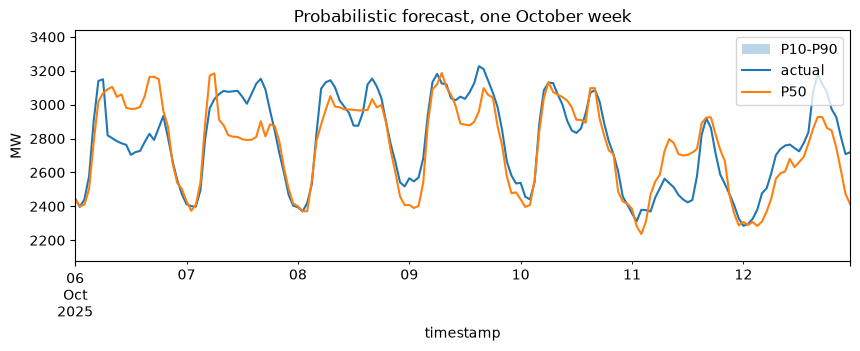

In [5]:
from sklearn.ensemble import GradientBoostingRegressor
# One model per quantile: same features, same trees — only the LOSS changes.
# alpha=0.1 trains a P10 (a floor), 0.5 the median, 0.9 a P90 (a ceiling).
qs = {}
for a in (0.1, 0.5, 0.9):
    g = GradientBoostingRegressor(loss="quantile", alpha=a, n_estimators=150,
                                  max_depth=3, random_state=0)
    g.fit(Xtr, ytr); qs[a] = g.predict(Xte)
import matplotlib.pyplot as plt
week = slice("2025-10-06", "2025-10-12")
idx = yte.loc[week].index
plt.figure(figsize=(10,3))
plt.fill_between(idx, pd.Series(qs[0.1], yte.index).loc[week],
                 pd.Series(qs[0.9], yte.index).loc[week], alpha=0.3, label="P10-P90")
yte.loc[week].plot(label="actual"); pd.Series(qs[0.5], yte.index).loc[week].plot(label="P50")
plt.legend(); plt.ylabel("MW"); plt.title("Probabilistic forecast, one October week");

### 3.2 Scoring a quantile

`pinball(y, q, alpha)` is the loss the models minimised, now used as the score: `d = y - q` is the miss; `np.maximum(alpha*d, (alpha-1)*d)` charges `alpha` per MW when the truth is above the quantile and `1-alpha` when below — the asymmetry that makes the P10 sit low and the P90 high. `cover` is the share of test hours where the truth fell between P10 and P90: a boolean per hour (`&` = both conditions), averaged.

**What you see:**

```
pinball P10 34.1 | P50 63.3 | P90 29.2
empirical coverage of the P10-P90 band: 76% (target: 80%)
```

The P50's pinball is half its MAE by construction (`0.5 · |d|`); the band claims 80 % and delivers 76 % — slightly too narrow, honest enough to say so.

In [6]:
# Pinball loss: being on the "wrong" side of the quantile costs alpha (or
# 1-alpha) per MW — the asymmetry that makes a quantile the optimal answer.
def pinball(y, q, alpha):
    d = y - q
    return float(np.mean(np.maximum(alpha*d, (alpha-1)*d)))
cover = float(((yte >= qs[0.1]) & (yte <= qs[0.9])).mean())
print(f"pinball P10 {pinball(yte, qs[0.1], .1):.1f} | P50 {pinball(yte, qs[0.5], .5):.1f} | "
      f"P90 {pinball(yte, qs[0.9], .9):.1f}")
print(f"empirical coverage of the P10-P90 band: {cover:.0%} (target: 80%)")

pinball P10 34.1 | P50 63.3 | P90 29.2
empirical coverage of the P10-P90 band: 76% (target: 80%)


Two honesty checks live in that cell: pinball loss is the *proper* score for a quantile (MAE would reward the median every time), and **coverage** asks whether the band means what it claims — an 80% band that contains the truth 60% of the time is a lie with error bars.

## Self-check

Two promises: both learners beat persistence on the untouched October period, and the P10–P90 band's coverage is in a sane range (0.6 to 0.95 — a band that held the truth 100 % of the time would be uselessly wide, one at 40 % is lying). **What you see:** `ALL OK — learners on the table, uncertainty quantified. Lab 9: same fight, your harness.`

In [7]:
assert mae["gbdt"] < mae["persistence(24h)"] and mae["linear"] < mae["persistence(24h)"], "both learners should beat persistence here"
assert 0.6 < cover < 0.95, "coverage catastrophically off"
print("ALL OK — learners on the table, uncertainty quantified. Lab 9: same fight, your harness.")

ALL OK — learners on the table, uncertainty quantified. Lab 9: same fight, your harness.


## 4. What you take to Labs 8 and 9

The feature table of section 1 is the input for every learner in Module 3: Lab 9 builds the same columns on your own series and pushes a learner through Lab 7's `walk_forward` (a learner's `model_fn` fits on the training rows and predicts the next day's rows). The temporal split, the persistence row as the floor, and the coverage check are the habits; Lab 8 reuses the fit/predict contract with classifiers.